# Economics and Finance

An economic report asks the same questions in the same order: how the big economies grew and when they shrank, which are the largest and how the order changed, how an economy's structure changes as it grows, where and when inflation bit, what the last shock cost, who caught up on income, and how the economies compare on every front at once. This page walks the world's major economies through those questions and names the figure that answers each, so the chart to reach for arrives with the question rather than the other way round. Every figure links to the chart guide that covers it in full.

Every number is real: the GDP growth of the United States, the euro area, China, Japan and the world since 1980, the nominal GDP of every country in six benchmark years, the sector shares of China, India and South Korea since 1960, and the inflation, growth, unemployment, trade, investment and income of the nineteen G20 countries, all from the World Bank's [World Development Indicators](https://datacatalog.worldbank.org/search/dataset/0037712) ([CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)). Swap the countries and the same cells draw it.

In [1]:
from datachart.charts import (
    BarChart,
    BumpChart,
    DumbbellChart,
    Heatmap,
    LineChart,
    ParallelCoords,
    StackedAreaChart,
)
from datachart.constants import (
    DUMBBELL_SORT_KEY,
    EMPHASIS,
    FIG_SIZE,
    LEGEND_LOCATION,
    NORMALIZE,
    ORIENTATION,
    SHOW_GRID,
    SORT,
    VALUE_FORMAT,
)
from datachart.utils import Grid

The hidden cell below holds the numbers. `GROWTH` is the yearly GDP growth of five economies over the `GROWTH_YEARS`; `GDP_RANK` is the nominal GDP, in trillions of current dollars, of every country that was among the ten largest in any of six benchmark years; `SECTORS` is the share of agriculture, industry and services in the GDP of three economies since 1960; `INFLATION` is the yearly consumer-price inflation of the G20 countries since 2015, `PANDEMIC` their growth in 2020, `INCOME` their GDP per capita in 2000 and 2023, and `G20_2023` six indicators of each in 2023 with its World Bank income group. The sections that follow only reshape those into the records the charts take.

In [2]:
# World Bank, World Development Indicators (CC BY 4.0), retrieved September 2026.
# yearly GDP growth (%), constant prices
GROWTH_YEARS = list(range(1980, 2025))
GROWTH = {
    'United States': [-0.3, 2.5, -1.8, 4.6, 7.2, 4.2, 3.5, 3.5, 4.2, 3.7, 1.9, -0.1, 3.5, 2.8, 4.0, 2.7, 3.8, 4.4, 4.5, 4.8, 4.1, 1.0, 1.7, 2.8, 3.8, 3.5, 2.8, 2.0, 0.1, -2.6, 2.7, 1.6, 2.3, 2.1, 2.5, 2.9, 1.8, 2.5, 3.0, 2.6, -2.1, 6.2, 2.5, 2.9, 2.8],
    'Euro area': [2.2, 0.6, 0.7, 1.4, 2.4, 2.3, 2.5, 2.6, 4.4, 4.1, 3.5, 2.3, 1.1, -0.7, 2.5, 2.5, 1.8, 2.7, 3.0, 3.0, 3.9, 2.2, 1.0, 0.8, 2.3, 1.8, 3.3, 3.0, 0.4, -4.5, 2.1, 1.8, -0.9, -0.2, 1.5, 2.1, 1.8, 2.6, 1.8, 1.6, -6.0, 6.4, 3.7, 0.5, 0.9],
    'China': [7.8, 5.1, 9.0, 10.8, 15.2, 13.4, 8.9, 11.7, 11.2, 4.2, 3.9, 9.4, 14.3, 13.9, 13.1, 11.0, 10.0, 9.3, 7.9, 7.7, 8.6, 8.3, 9.2, 10.1, 10.1, 11.5, 12.7, 14.2, 9.7, 9.4, 10.6, 9.5, 7.9, 7.8, 7.5, 7.0, 6.8, 6.9, 6.8, 6.1, 2.3, 8.6, 3.1, 5.4, 5.0],
    'Japan': [2.8, 4.2, 3.3, 3.5, 4.5, 5.2, 3.3, 4.7, 6.8, 4.9, 4.9, 3.4, 0.8, -0.5, 1.0, 2.3, 3.1, 1.4, -1.8, -0.3, 3.0, 0.3, 0.1, 1.4, 2.1, 1.8, 1.5, 1.7, -1.2, -5.9, 4.1, -0.2, 1.6, 2.0, 0.9, 1.8, 0.7, 1.6, 0.8, -0.3, -4.3, 3.6, 1.3, 0.7, -0.2],
    'World': [1.8, 1.9, 0.4, 2.6, 4.7, 3.7, 3.3, 3.8, 4.5, 3.6, 2.7, 1.2, 2.1, 1.9, 3.4, 3.2, 3.6, 4.0, 2.8, 3.6, 4.6, 2.0, 2.3, 3.1, 4.5, 4.1, 4.5, 4.4, 2.1, -1.3, 4.5, 3.3, 2.7, 2.9, 3.2, 3.1, 2.8, 3.4, 3.3, 2.7, -2.9, 6.5, 3.4, 2.9, 2.9],
}

# nominal GDP (trillions of current US dollars) as (year, value), for every country in a
# top ten of 1980, 1990, 2000, 2010, 2020 or 2023; a series starts when its data does
GDP_RANK = {
    'United States': [(1980, 2.86), (1990, 5.96), (2000, 10.25), (2010, 15.05), (2020, 21.38), (2023, 27.81)],
    'Japan': [(1980, 1.15), (1990, 3.25), (2000, 5.04), (2010, 5.81), (2020, 5.19), (2023, 4.38)],
    'Germany': [(1980, 0.95), (1990, 1.78), (2000, 1.97), (2010, 3.47), (2020, 3.94), (2023, 4.56)],
    'France': [(1980, 0.69), (1990, 1.26), (2000, 1.36), (2010, 2.65), (2020, 2.65), (2023, 3.06)],
    'United Kingdom': [(1980, 0.56), (1990, 1.09), (2000, 1.67), (2010, 2.5), (2020, 2.72), (2023, 3.42)],
    'Italy': [(1980, 0.48), (1990, 1.18), (2000, 1.15), (2010, 2.14), (2020, 1.91), (2023, 2.32)],
    'Canada': [(1980, 0.27), (1990, 0.6), (2000, 0.74), (2010, 1.62), (2020, 1.66), (2023, 2.2)],
    'Brazil': [(1980, 0.24), (1990, 0.38), (2000, 0.66), (2010, 2.21), (2020, 1.48), (2023, 2.19)],
    'Spain': [(1980, 0.23), (1990, 0.54), (2000, 0.6), (2010, 1.43), (2020, 1.29), (2023, 1.62)],
    'Mexico': [(1980, 0.21), (1990, 0.26), (2000, 0.74), (2010, 1.11), (2020, 1.12), (2023, 1.79)],
    'Russia': [(1990, 0.52), (2000, 0.26), (2010, 1.52), (2020, 1.49), (2023, 2.05)],
    'China': [(1980, 0.19), (1990, 0.36), (2000, 1.22), (2010, 6.19), (2020, 15.0), (2023, 18.27)],
    'India': [(1980, 0.19), (1990, 0.32), (2000, 0.47), (2010, 1.68), (2020, 2.67), (2023, 3.5)],
    'South Korea': [(1980, 0.07), (1990, 0.29), (2000, 0.6), (2010, 1.19), (2020, 1.74), (2023, 1.84)],
}

# (agriculture, industry, services) value added as % of GDP, by year
SECTORS = {
    'China': {
        1960: (23.1, 44.3, 32.6),
        1961: (35.7, 31.9, 32.4),
        1962: (38.9, 31.2, 29.8),
        1963: (39.8, 33.0, 27.2),
        1964: (38.0, 35.3, 26.8),
        1965: (37.5, 35.0, 27.5),
        1966: (37.1, 37.8, 25.1),
        1967: (39.7, 33.8, 26.4),
        1968: (41.6, 31.1, 27.4),
        1969: (37.5, 35.4, 27.2),
        1970: (34.7, 40.2, 25.1),
        1971: (33.6, 41.9, 24.6),
        1972: (32.4, 42.7, 24.9),
        1973: (32.9, 42.8, 24.4),
        1974: (33.4, 42.4, 24.3),
        1975: (31.9, 45.3, 22.8),
        1976: (32.3, 45.0, 22.7),
        1977: (28.9, 46.6, 24.4),
        1978: (27.6, 47.6, 24.7),
        1979: (30.7, 46.9, 22.5),
        1980: (29.6, 48.0, 22.4),
        1981: (31.3, 45.9, 22.9),
        1982: (32.7, 44.5, 22.7),
        1983: (32.5, 44.1, 23.4),
        1984: (31.5, 42.8, 25.7),
        1985: (27.9, 42.6, 29.5),
        1986: (26.6, 43.4, 30.0),
        1987: (26.3, 43.2, 30.5),
        1988: (25.2, 43.5, 31.4),
        1989: (24.6, 42.4, 33.0),
        1990: (26.5, 41.0, 32.5),
        1991: (24.0, 41.4, 34.7),
        1992: (21.2, 43.0, 35.8),
        1993: (19.2, 46.0, 34.8),
        1994: (19.4, 46.0, 34.7),
        1995: (19.5, 46.5, 34.0),
        1996: (19.2, 46.8, 33.9),
        1997: (17.8, 46.8, 35.4),
        1998: (17.0, 45.4, 37.5),
        1999: (15.9, 45.0, 39.1),
        2000: (14.5, 45.1, 40.4),
        2001: (13.8, 44.3, 41.9),
        2002: (13.1, 43.9, 43.0),
        2003: (12.2, 45.0, 42.8),
        2004: (12.7, 45.2, 42.0),
        2005: (11.5, 46.4, 42.1),
        2006: (10.5, 46.9, 42.6),
        2007: (10.1, 46.2, 43.7),
        2008: (10.0, 46.2, 43.8),
        2009: (9.5, 45.2, 45.3),
        2010: (9.2, 45.7, 45.1),
        2011: (9.0, 45.8, 45.2),
        2012: (9.0, 44.7, 46.4),
        2013: (8.8, 43.4, 47.8),
        2014: (8.5, 42.3, 49.2),
        2015: (8.2, 40.0, 51.7),
        2016: (7.9, 38.8, 53.3),
        2017: (7.3, 39.1, 53.5),
        2018: (6.9, 39.0, 54.1),
        2019: (7.0, 37.8, 55.2),
        2020: (7.5, 36.9, 55.5),
        2021: (7.1, 38.1, 54.8),
        2022: (7.1, 37.9, 55.0),
        2023: (6.9, 36.8, 56.3),
    },
    'India': {
        1960: (41.7, 20.8, 38.8),
        1961: (41.1, 21.4, 38.3),
        1962: (39.1, 22.1, 39.9),
        1963: (39.8, 21.9, 38.1),
        1964: (41.3, 21.0, 36.3),
        1965: (39.4, 21.7, 37.5),
        1966: (40.4, 21.4, 36.5),
        1967: (42.8, 20.1, 34.6),
        1968: (42.1, 20.6, 35.1),
        1969: (41.6, 21.4, 34.3),
        1970: (40.3, 21.7, 35.0),
        1971: (38.6, 22.4, 35.8),
        1972: (38.6, 22.4, 35.5),
        1973: (41.6, 21.3, 32.9),
        1974: (38.9, 22.7, 33.6),
        1975: (36.0, 23.2, 35.1),
        1976: (34.3, 24.5, 35.8),
        1977: (35.8, 24.4, 34.7),
        1978: (34.3, 25.3, 34.9),
        1979: (32.8, 26.0, 35.5),
        1980: (34.4, 25.3, 33.8),
        1981: (33.3, 26.1, 33.9),
        1982: (32.3, 26.1, 34.9),
        1983: (32.6, 26.3, 34.5),
        1984: (31.4, 26.7, 35.4),
        1985: (29.7, 26.6, 36.1),
        1986: (28.6, 26.7, 37.0),
        1987: (28.0, 26.7, 37.5),
        1988: (28.8, 26.7, 36.8),
        1989: (27.8, 27.6, 37.2),
        1990: (27.6, 27.5, 37.0),
        1991: (27.7, 26.4, 37.8),
        1992: (26.9, 26.8, 37.9),
        1993: (27.1, 26.8, 38.5),
        1994: (26.5, 27.6, 37.5),
        1995: (24.5, 28.6, 37.8),
        1996: (25.2, 27.9, 37.7),
        1997: (24.2, 27.8, 39.1),
        1998: (24.2, 27.3, 40.1),
        1999: (23.0, 26.5, 42.0),
        2000: (21.6, 27.3, 42.7),
        2001: (21.6, 26.5, 43.8),
        2002: (19.5, 27.7, 44.7),
        2003: (19.6, 27.5, 44.7),
        2004: (17.8, 29.2, 44.1),
        2005: (17.6, 29.5, 44.4),
        2006: (16.8, 30.9, 44.0),
        2007: (16.8, 30.9, 44.0),
        2008: (16.8, 31.1, 45.9),
        2009: (16.7, 31.1, 46.0),
        2010: (17.0, 30.7, 45.0),
        2011: (17.2, 30.2, 45.4),
        2012: (16.8, 29.4, 46.3),
        2013: (17.1, 28.4, 46.7),
        2014: (16.8, 27.7, 47.8),
        2015: (16.2, 27.3, 47.8),
        2016: (16.4, 26.6, 47.7),
        2017: (16.6, 26.5, 47.7),
        2018: (16.0, 26.4, 48.4),
        2019: (16.8, 24.6, 50.1),
        2020: (18.7, 25.1, 47.9),
        2021: (17.4, 26.5, 47.8),
        2022: (18.2, 25.6, 47.2),
        2023: (17.7, 25.6, 47.6),
    },
    'South Korea': {
        1960: (36.4, 17.3, 39.3),
        1961: (38.5, 17.8, 37.8),
        1962: (36.5, 17.8, 38.6),
        1963: (42.9, 18.0, 33.6),
        1964: (46.3, 19.3, 30.2),
        1965: (37.3, 23.2, 34.2),
        1966: (34.2, 22.9, 36.5),
        1967: (30.0, 23.2, 39.6),
        1968: (27.9, 23.9, 39.7),
        1969: (27.2, 24.4, 39.8),
        1970: (26.3, 24.6, 40.4),
        1971: (26.9, 23.1, 41.7),
        1972: (26.2, 24.6, 42.0),
        1973: (24.3, 27.3, 41.2),
        1974: (23.8, 26.2, 41.8),
        1975: (24.1, 26.3, 40.5),
        1976: (22.7, 27.3, 40.0),
        1977: (21.4, 28.1, 40.2),
        1978: (19.6, 29.8, 39.9),
        1979: (18.2, 31.2, 40.1),
        1980: (14.0, 31.7, 43.7),
        1981: (14.7, 30.9, 43.9),
        1982: (13.7, 31.3, 44.5),
        1983: (12.3, 32.6, 43.9),
        1984: (11.6, 34.2, 43.9),
        1985: (11.5, 33.7, 45.0),
        1986: (10.1, 34.6, 45.6),
        1987: (9.0, 35.7, 45.9),
        1988: (8.9, 36.3, 45.6),
        1989: (8.3, 35.9, 47.0),
        1990: (7.4, 36.1, 47.2),
        1991: (6.6, 37.0, 47.8),
        1992: (6.4, 35.8, 49.1),
        1993: (5.7, 36.1, 49.7),
        1994: (5.5, 36.2, 49.7),
        1995: (5.1, 36.5, 49.7),
        1996: (4.8, 35.5, 50.7),
        1997: (4.3, 35.3, 51.3),
        1998: (4.1, 35.1, 52.9),
        1999: (4.1, 34.3, 52.5),
        2000: (3.7, 34.4, 52.5),
        2001: (3.4, 33.1, 53.7),
        2002: (3.1, 32.7, 54.2),
        2003: (2.8, 33.0, 54.5),
        2004: (2.8, 34.6, 53.7),
        2005: (2.5, 34.1, 54.4),
        2006: (2.4, 33.5, 55.2),
        2007: (2.2, 33.5, 55.5),
        2008: (2.0, 32.6, 56.6),
        2009: (2.1, 33.1, 56.3),
        2010: (2.0, 34.4, 54.9),
        2011: (2.1, 34.9, 54.7),
        2012: (2.1, 34.7, 55.0),
        2013: (2.0, 35.2, 54.9),
        2014: (2.0, 35.0, 55.2),
        2015: (1.9, 35.1, 55.1),
        2016: (1.7, 35.2, 55.0),
        2017: (1.7, 35.6, 54.6),
        2018: (1.6, 35.0, 55.4),
        2019: (1.5, 33.6, 56.9),
        2020: (1.6, 33.4, 56.9),
        2021: (1.7, 33.2, 56.9),
        2022: (1.4, 32.5, 58.1),
        2023: (1.4, 32.5, 58.9),
    },
}

# G20 members: consumer-price inflation (%) per year, 2015 to 2023; Argentina published
# no national index for 2015-2017, so those cells are None
INFLATION_YEARS = list(range(2015, 2024))
INFLATION = {
    'Argentina': [None, None, None, 34.3, 53.5, 42.0, 48.4, 72.4, 133.5],
    'Australia': [1.5, 1.3, 1.9, 1.9, 1.6, 0.8, 2.9, 6.6, 5.6],
    'Brazil': [9.0, 8.7, 3.4, 3.7, 3.7, 3.2, 8.3, 9.3, 4.6],
    'Canada': [1.1, 1.4, 1.6, 2.3, 1.9, 0.7, 3.4, 6.8, 3.9],
    'China': [1.4, 2.0, 1.6, 2.1, 2.9, 2.4, 1.0, 2.0, 0.2],
    'France': [0.0, 0.2, 1.0, 1.9, 1.1, 0.5, 1.6, 5.2, 4.9],
    'Germany': [0.5, 0.5, 1.5, 1.7, 1.4, 0.1, 3.1, 6.9, 5.9],
    'India': [4.9, 4.9, 3.3, 3.9, 3.7, 6.6, 5.1, 6.7, 5.6],
    'Indonesia': [6.4, 3.5, 3.8, 3.2, 3.0, 1.9, 1.6, 4.2, 3.7],
    'Italy': [0.0, -0.1, 1.2, 1.1, 0.6, -0.1, 1.9, 8.2, 5.6],
    'Japan': [0.8, -0.1, 0.5, 1.0, 0.5, -0.0, -0.2, 2.5, 3.3],
    'South Korea': [0.7, 1.0, 1.9, 1.5, 0.4, 0.5, 2.5, 5.1, 3.6],
    'Mexico': [2.7, 2.8, 6.0, 4.9, 3.6, 3.4, 5.7, 7.9, 5.5],
    'Russia': [15.5, 7.0, 3.7, 2.9, 4.5, 3.4, 6.7, 13.7, 5.9],
    'Saudi Arabia': [1.2, 2.1, -0.8, 2.5, -1.2, 3.4, 3.1, 2.5, 2.3],
    'South Africa': [4.5, 6.6, 5.2, 4.5, 4.1, 3.2, 4.6, 7.0, 6.1],
    'Türkiye': [7.7, 7.8, 11.1, 16.3, 15.2, 12.3, 19.6, 72.3, 53.9],
    'United Kingdom': [0.4, 1.0, 2.6, 2.3, 1.7, 1.0, 2.5, 7.9, 6.8],
    'United States': [0.1, 1.3, 2.1, 2.4, 1.8, 1.2, 4.7, 8.0, 4.1],
}

# G20 members: GDP growth in 2020 (%)
PANDEMIC = {
    'Argentina': -9.9,
    'Australia': -0.1,
    'Brazil': -3.3,
    'Canada': -5.0,
    'China': 2.3,
    'France': -7.4,
    'Germany': -4.1,
    'India': -5.8,
    'Indonesia': -2.1,
    'Italy': -8.9,
    'Japan': -4.3,
    'South Korea': -0.7,
    'Mexico': -8.4,
    'Russia': -2.7,
    'Saudi Arabia': -3.8,
    'South Africa': -6.2,
    'Türkiye': 1.8,
    'United Kingdom': -10.0,
    'United States': -2.1,
}

# G20 members: GDP per capita (2021 PPP dollars) in 2000 and 2023
INCOME = {
    'Argentina': (22281, 27230),
    'Australia': (45099, 60685),
    'Brazil': (14005, 19080),
    'Canada': (48399, 58088),
    'China': (4066, 22687),
    'France': (45922, 54297),
    'Germany': (49956, 63140),
    'India': (3010, 8871),
    'Indonesia': (6056, 13890),
    'Italy': (50353, 52843),
    'Japan': (39732, 47387),
    'South Korea': (26404, 54029),
    'Mexico': (20470, 21865),
    'Russia': (20105, 39881),
    'Saudi Arabia': (55962, 64482),
    'South Africa': (11184, 13695),
    'Türkiye': (14857, 35069),
    'United Kingdom': (43818, 53423),
    'United States': (55046, 74352),
}

# G20 members in 2023, without Argentina and Türkiye, whose inflation would flatten every other axis
G20_2023 = [
    {'country': 'Australia', 'income': 'High', 'GDP growth (%)': 3.6, 'Inflation (%)': 5.6, 'Unemployment (%)': 3.7, 'Current account (% of GDP)': -0.4, 'Trade (% of GDP)': 49.0, 'Investment (% of GDP)': 23.9},
    {'country': 'Brazil', 'income': 'Upper middle', 'GDP growth (%)': 3.2, 'Inflation (%)': 4.6, 'Unemployment (%)': 7.9, 'Current account (% of GDP)': -1.2, 'Trade (% of GDP)': 33.7, 'Investment (% of GDP)': 15.8},
    {'country': 'Canada', 'income': 'High', 'GDP growth (%)': 2.0, 'Inflation (%)': 3.9, 'Unemployment (%)': 5.4, 'Current account (% of GDP)': -0.7, 'Trade (% of GDP)': 66.6, 'Investment (% of GDP)': 23.6},
    {'country': 'China', 'income': 'Upper middle', 'GDP growth (%)': 5.4, 'Inflation (%)': 0.2, 'Unemployment (%)': 4.7, 'Current account (% of GDP)': 1.4, 'Trade (% of GDP)': 36.7, 'Investment (% of GDP)': 41.1},
    {'country': 'France', 'income': 'High', 'GDP growth (%)': 1.4, 'Inflation (%)': 4.9, 'Unemployment (%)': 7.3, 'Current account (% of GDP)': -1.0, 'Trade (% of GDP)': 70.6, 'Investment (% of GDP)': 22.9},
    {'country': 'Germany', 'income': 'High', 'GDP growth (%)': -0.9, 'Inflation (%)': 5.9, 'Unemployment (%)': 3.1, 'Current account (% of GDP)': 5.5, 'Trade (% of GDP)': 82.0, 'Investment (% of GDP)': 22.0},
    {'country': 'India', 'income': 'Lower middle', 'GDP growth (%)': 7.2, 'Inflation (%)': 5.6, 'Unemployment (%)': 4.2, 'Current account (% of GDP)': -0.9, 'Trade (% of GDP)': 46.3, 'Investment (% of GDP)': 34.5},
    {'country': 'Indonesia', 'income': 'Upper middle', 'GDP growth (%)': 5.0, 'Inflation (%)': 3.7, 'Unemployment (%)': 3.3, 'Current account (% of GDP)': -0.1, 'Trade (% of GDP)': 41.5, 'Investment (% of GDP)': 30.3},
    {'country': 'Italy', 'income': 'High', 'GDP growth (%)': 0.9, 'Inflation (%)': 5.6, 'Unemployment (%)': 7.6, 'Current account (% of GDP)': 0.3, 'Trade (% of GDP)': 65.1, 'Investment (% of GDP)': 23.1},
    {'country': 'Japan', 'income': 'High', 'GDP growth (%)': 0.7, 'Inflation (%)': 3.3, 'Unemployment (%)': 2.6, 'Current account (% of GDP)': 3.6, 'Trade (% of GDP)': 43.6, 'Investment (% of GDP)': 27.8},
    {'country': 'South Korea', 'income': 'High', 'GDP growth (%)': 1.6, 'Inflation (%)': 3.6, 'Unemployment (%)': 2.7, 'Current account (% of GDP)': 1.8, 'Trade (% of GDP)': 82.3, 'Investment (% of GDP)': 31.9},
    {'country': 'Mexico', 'income': 'Upper middle', 'GDP growth (%)': 3.1, 'Inflation (%)': 5.5, 'Unemployment (%)': 2.8, 'Current account (% of GDP)': -0.7, 'Trade (% of GDP)': 73.7, 'Investment (% of GDP)': 23.3},
    {'country': 'Russia', 'income': 'High', 'GDP growth (%)': 4.1, 'Inflation (%)': 5.9, 'Unemployment (%)': 3.1, 'Current account (% of GDP)': 2.4, 'Trade (% of GDP)': 41.3, 'Investment (% of GDP)': 27.3},
    {'country': 'Saudi Arabia', 'income': 'High', 'GDP growth (%)': 0.5, 'Inflation (%)': 2.3, 'Unemployment (%)': 4.0, 'Current account (% of GDP)': 2.1, 'Trade (% of GDP)': 55.8, 'Investment (% of GDP)': 29.8},
    {'country': 'South Africa', 'income': 'Upper middle', 'GDP growth (%)': 0.8, 'Inflation (%)': 6.1, 'Unemployment (%)': 32.1, 'Current account (% of GDP)': -1.1, 'Trade (% of GDP)': 65.7, 'Investment (% of GDP)': 15.4},
    {'country': 'United Kingdom', 'income': 'High', 'GDP growth (%)': 0.3, 'Inflation (%)': 6.8, 'Unemployment (%)': 4.0, 'Current account (% of GDP)': -3.6, 'Trade (% of GDP)': 65.0, 'Investment (% of GDP)': 18.5},
    {'country': 'United States', 'income': 'High', 'GDP growth (%)': 2.9, 'Inflation (%)': 4.1, 'Unemployment (%)': 3.6, 'Current account (% of GDP)': -3.3, 'Trade (% of GDP)': 24.9, 'Investment (% of GDP)': 21.6},
]

## Growth

### How did the big economies grow, and when did they shrink?

The first figure of an economic report is growth over time, one line per economy, and the years that matter are the ones below zero. A [line chart](../../how-to-guides/charts/linechart/) draws the five series over the same years, an `hlines` mark at zero is the line a contraction crosses, and the two global recessions are `vspans`, shaded bands with a `label` that enters the legend, so the reader sees at once which lines dipped into them and which did not. The world line takes the `"highlight"` role through `emphasis`, drawn bold in front of the others, because it is the one the rest are read against.

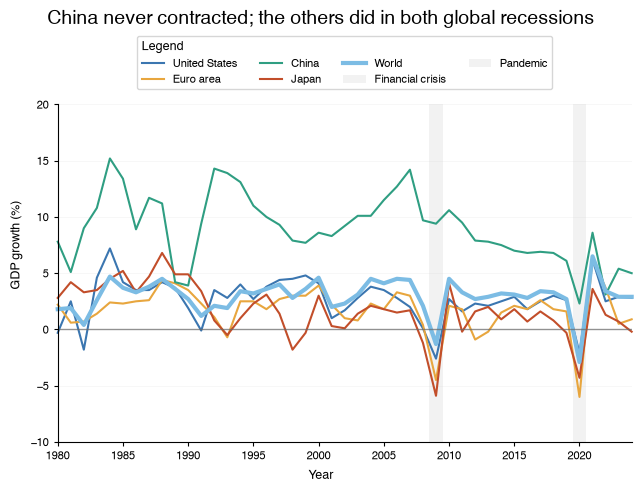

In [3]:
ECONOMIES = list(GROWTH)
RECESSIONS = [
    {"xmin": 2008.5, "xmax": 2009.5, "label": "Financial crisis"},
    {"xmin": 2019.5, "xmax": 2020.5, "label": "Pandemic"},
]
ZERO_LINE = {"plot_hline_color": "#666666", "plot_hline_width": 1}

growth_figure = LineChart(
    [
        [{"x": year, "y": value} for year, value in zip(GROWTH_YEARS, GROWTH[economy])]
        for economy in ECONOMIES
    ],
    title="China never contracted; the others did in both global recessions",
    xlabel="Year",
    ylabel="GDP growth (%)",
    subtitle=ECONOMIES,
    # the world line bold and in front, the rest at normal weight
    emphasis=[None if economy != "World" else EMPHASIS.HIGHLIGHT for economy in ECONOMIES],
    hlines={"y": 0, "style": ZERO_LINE},
    vspans=RECESSIONS,
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_TOP, "ncols": 4},
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_MEDIUM,
)
growth_figure.show()

The world line runs between 2 and 5% for four decades and dips below zero only twice, in 2009 at -1.3% and in 2020 at -2.9%, which is what the two bands mark. Inside the bands the lines separate: the euro area and Japan fell furthest both times, the United States less, and China's line never crosses zero at all; its worst year was 2020 at 2.3%. Outside the bands, China's line sits far above the others through the 1990s and 2000s and has drifted down towards them since, which is the growth the next figure turns into rank.

### Which economies are the largest, and how has the order changed?

The size of an economy is a ranking: a report says "the second-largest economy", not its dollar figure. A [bump chart](../../how-to-guides/charts/bumpchart/) draws rankings over time: one line per country, its vertical position each benchmark year is its rank by nominal GDP, and a line that climbs is a country overtaking the others. The chart ranks the raw values itself, so the records carry GDP in trillions and `subtitle` names the lines at their ends. Fourteen lines crossing is a tangle, and `emphasis` cuts it: the two lines the section is about take the `"highlight"` role and the rest the `"background"` role, drawn thin and grey, so the two bold lines carry the story and the others are the context they climb through. A series starts when the country's data does, so Russia's line begins in 1990.

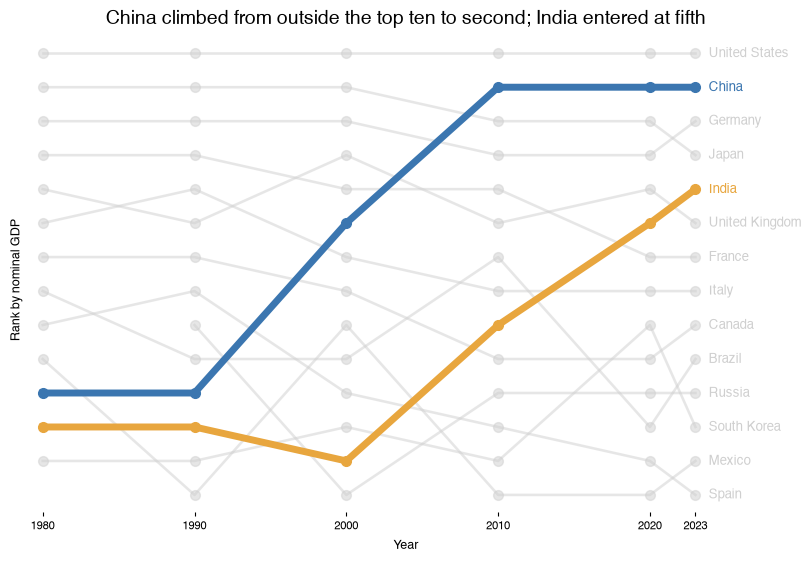

In [4]:
COUNTRIES = list(GDP_RANK)

rank_figure = BumpChart(
    [[{"x": year, "y": gdp} for year, gdp in GDP_RANK[country]] for country in COUNTRIES],
    title="China climbed from outside the top ten to second; India entered at fifth",
    xlabel="Year",
    ylabel="Rank by nominal GDP",
    subtitle=COUNTRIES,
    # the two climbers bold, everyone else as grey context
    emphasis=[
        EMPHASIS.HIGHLIGHT if country in ("China", "India") else EMPHASIS.BACKGROUND
        for country in COUNTRIES
    ],
    xticks=[year for year, _ in GDP_RANK["United States"]],
    figsize=(8.0, 5.5),
)
rank_figure.show()

The United States holds first place in every year, and Japan holds second for three decades before China passes it in 2010 and Germany in 2023. China's line carries the figure: 12th in 1980, 11th in 1990, 6th in 2000, and second since 2010. India's line enters the top ten in 2010 and reaches fifth in 2023. The other lines drift down a place or two as the two Asian economies pass them.

### How does an economy change as it grows?

Every economy that grows rich goes through the same structural change: agriculture shrinks, industry rises and then yields to services. Three economies at different stages of it show the whole path. The three sector shares add up to nearly the whole of GDP (the remainder is net taxes), so each economy is a [stacked area chart](../../how-to-guides/charts/stackedareachart/) with the bands stacked to the whole. Three charts built with the same `ymax` sit side by side in a [Grid](../../how-to-guides/utility/grid/), which takes the figures already built and redraws them into its cells, so the reader compares the boundaries across the three at the same scale.

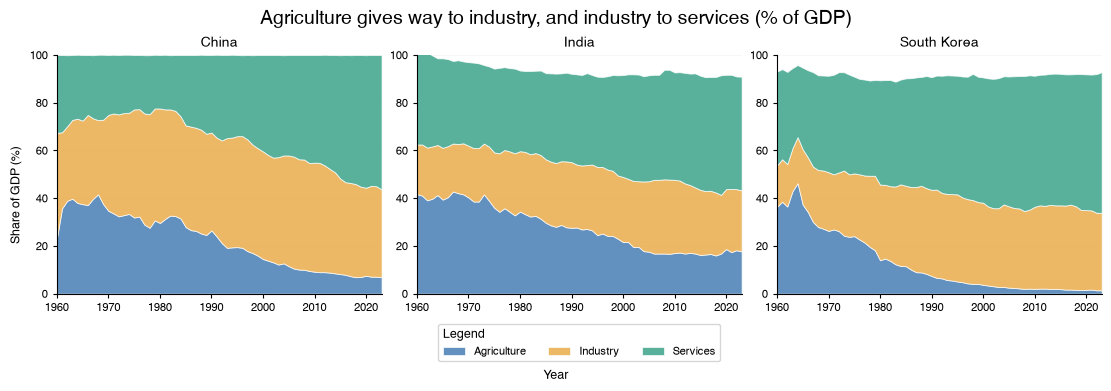

In [5]:
SECTOR_NAMES = ["Agriculture", "Industry", "Services"]


def structure(economy):
    years = sorted(SECTORS[economy])
    return StackedAreaChart(
        [
            [{"x": year, "y": SECTORS[economy][year][index]} for year in years]
            for index in range(len(SECTOR_NAMES))
        ],
        title=economy,
        subtitle=SECTOR_NAMES,
        ymax=100,
        # one legend for the row, below the middle chart
        show_legend=economy == "India",
        legend={"location": LEGEND_LOCATION.OUTSIDE_BOTTOM, "ncols": 3},
    )


Grid(
    [structure(economy) for economy in SECTORS],
    title="Agriculture gives way to industry, and industry to services (% of GDP)",
    xlabel="Year",
    ylabel="Share of GDP (%)",
    figsize=(11.0, 3.8),
).show()

South Korea is the finished path: agriculture was 36% of GDP in 1960 and is 1% now, industry rose through the 1970s and 1980s and has held near a third since, and services took the rest. China is the same path forty years behind, with industry still near 37% and services passing it only around 2012. India skipped a step: its agriculture band shrank the same way, but industry never rose past a third and services took the share directly.

## Prices, incomes and the shocks

### Where and when did inflation bite?

Nineteen countries over nine years of inflation is a table a reader cannot scan for the hot years; a [heatmap](../../how-to-guides/charts/heatmap/) colours each cell by its value, so a hot year is a dark column and a chronically inflationary country is a dark row. Two members run inflation in the tens and hundreds of percent, which would leave every other cell the same pale shade on a linear scale, so `norm=NORMALIZE.SYMLOG` gives the colour scale a logarithmic reach that keeps the contrast among the single digits, and `show_heatmap_values` prints the numbers so the extreme cells are read rather than guessed.

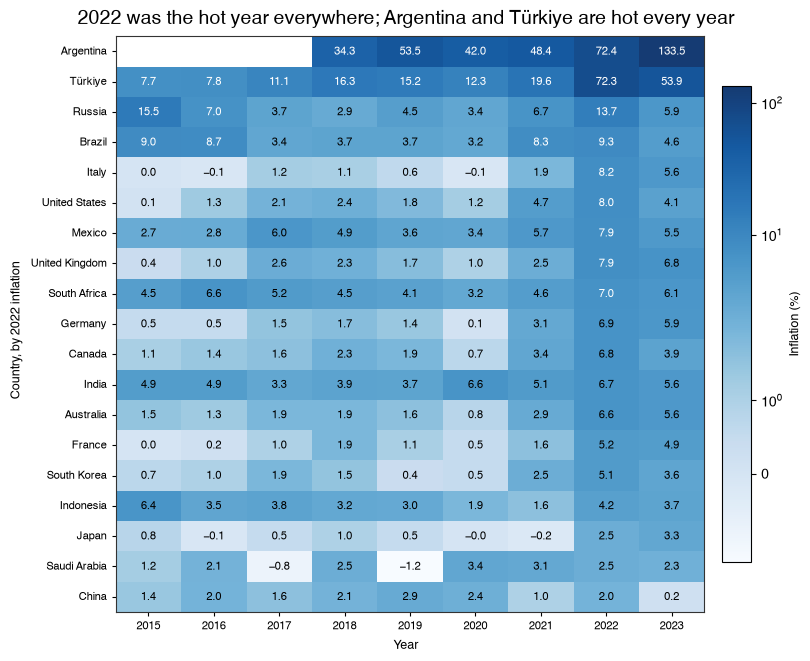

In [6]:
MEMBERS = sorted(INFLATION, key=lambda country: -INFLATION[country][INFLATION_YEARS.index(2022)])

inflation_figure = Heatmap(
    {"x": INFLATION_YEARS, "y": MEMBERS, "z": [INFLATION[country] for country in MEMBERS]},
    title="2022 was the hot year everywhere; Argentina and Türkiye are hot every year",
    xlabel="Year",
    ylabel="Country, by 2022 inflation",
    norm=NORMALIZE.SYMLOG,
    show_heatmap_values=True,
    valfmt="{x:.1f}",
    show_colorbars=True,
    colorbar={"label": "Inflation (%)"},
    figsize=(8.0, 6.5),
)
inflation_figure.show()

The 2022 column is the darkest for almost every row: the post-pandemic surge took Germany to 7% and Italy to 8%, the United Kingdom to 8% and the United States to 8%, and 2023 is already paler. Two rows are dark in every column, Argentina and Türkiye, where inflation is a condition rather than an episode, and two are pale in every column, China and Japan, which never saw the surge. Saudi Arabia is pale throughout too, with a pegged currency and subsidised prices. The heatmap separates the episode from the condition.

### How much did the pandemic year cost?

One year, nineteen economies, one number each: the growth of 2020 is a [bar chart](../../how-to-guides/charts/barchart/), sorted so the reader sees the order without reading the labels, with a `vlines` mark at zero as the line the bars are measured from. The bars run sideways, with `orientation`, so the country names read as a list and the value axis is horizontal, `show_values` prints each figure at the bar's end, and each record's own `emphasis` gives the economies that grew in the pandemic year the `"highlight"` role and the rest the `"background"` role, because the two that grew are the exception the report has to explain.

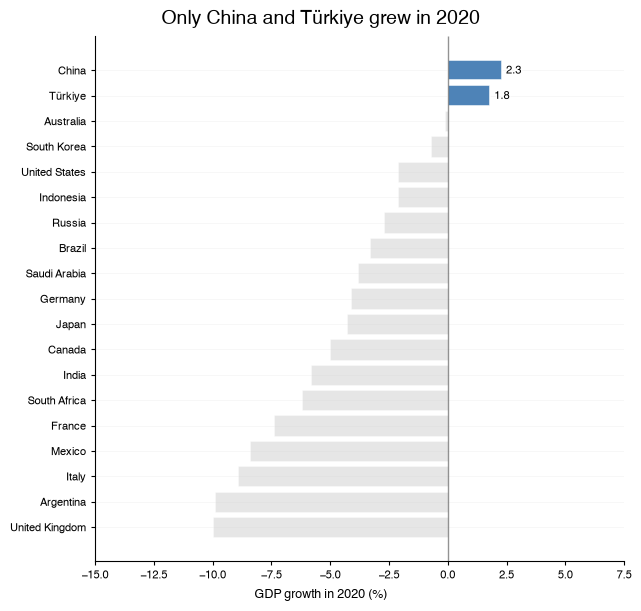

In [7]:
pandemic_figure = BarChart(
    [
        {
            "label": country,
            "y": growth,
            "emphasis": EMPHASIS.HIGHLIGHT if growth > 0 else EMPHASIS.BACKGROUND,
        }
        for country, growth in PANDEMIC.items()
    ],
    title="Only China and Türkiye grew in 2020",
    xlabel="GDP growth in 2020 (%)",
    orientation=ORIENTATION.HORIZONTAL,
    sort=SORT.ASCENDING,
    show_values=True,
    value_format=VALUE_FORMAT.DECIMAL,
    # the value axis is horizontal, so the zero line is vertical
    vlines={"x": 0, "style": {"plot_vline_color": "#666666", "plot_vline_width": 1}},
    figsize=(6.3, 6.0),
)
pandemic_figure.show()

China and Türkiye are the only bars to the right of the line, at 2.3 and 1.8%. Everyone else contracted: the United Kingdom at -10.0% with Argentina, Italy and Mexico close behind, and Australia, South Korea, Indonesia and the United States at the top with falls of 2.1% or less. The figure is one year; the growth chart above shows the world back above zero in 2021.

### Who caught up on income?

Growth rates compound into income levels, and the level is what a household feels. GDP per capita in 2000 and 2023, at purchasing-power parity so the dollars buy the same basket everywhere, is a before-and-after question for a [dumbbell chart](../../how-to-guides/charts/dumbbellchart/): a dot at each year and the connector between them is the gain. `sort_by` the 2023 value puts the richest at the top, and `show_values="delta"` prints each gain at its connector, so a long connector low on the chart is a country catching up and a short one high on it is a rich country growing slowly.

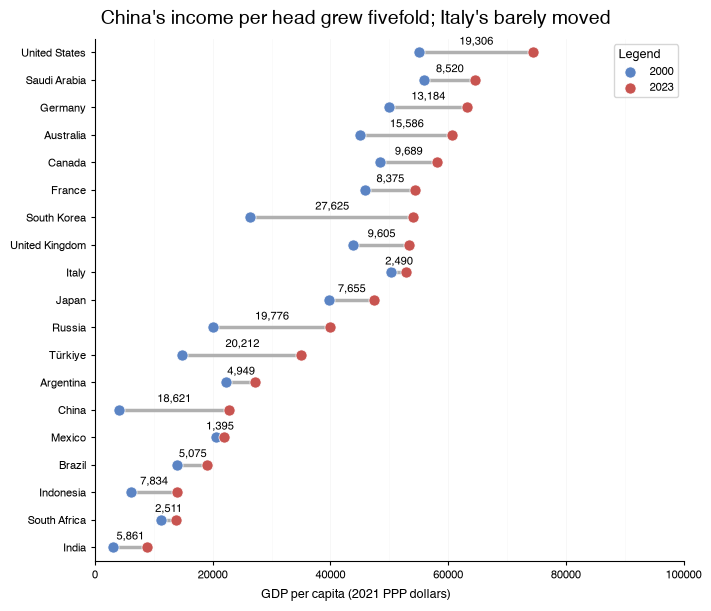

In [8]:
income_figure = DumbbellChart(
    [{"label": country, "start": start, "end": end} for country, (start, end) in INCOME.items()],
    title="China's income per head grew fivefold; Italy's barely moved",
    xlabel="GDP per capita (2021 PPP dollars)",
    start_name="2000",
    end_name="2023",
    sort=SORT.DESCENDING,
    sort_by=DUMBBELL_SORT_KEY.END,
    show_values="delta",
    value_format=VALUE_FORMAT.THOUSANDS,
    show_legend=True,
    figsize=(7.0, 6.0),
)
income_figure.show()

The connectors at the top are long in dollars and short in proportion: the United States added 19,306 dollars, a gain of 35%. Lower down the connectors are the reverse. China multiplied its income per head by 5.6, India by 2.9, and both are still in the lower half of the chart, which says how far they started from. Italy, with a gain of 5%, grew least, and the euro-area members and Japan sit just above it. Convergence is under way, and this figure says how much of the gap is left.

### How do the economies compare on every front at once?

A report ends with the table (growth, inflation, unemployment, the current account, trade and investment for every country), and a table of six columns and seventeen rows is read one column at a time. A [parallel coordinates chart](../../how-to-guides/charts/parallelcoords/) draws every column as its own axis and every country as a line across them, so a country's profile is a shape and the countries that look alike run together. `dimensions` picks the axes, every key of the records but the name and the group, and `hue` colours the lines by the World Bank income group, which is the grouping the profiles are expected to follow. Argentina and Türkiye are left off, because their inflation would squash every other line to the bottom of that axis.

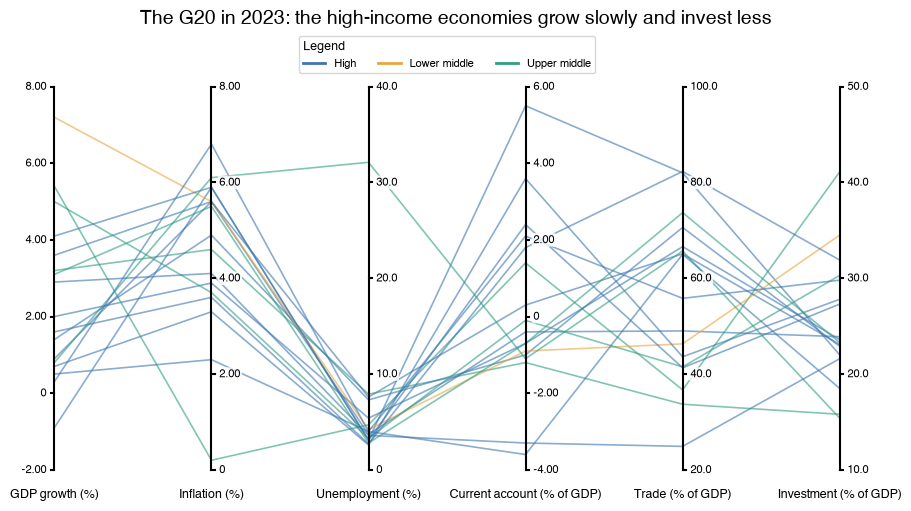

In [9]:
DIMENSIONS = [key for key in G20_2023[0] if key not in ("country", "income")]

profile_figure = ParallelCoords(
    G20_2023,
    title="The G20 in 2023: the high-income economies grow slowly and invest less",
    dimensions=DIMENSIONS,
    hue="income",
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_TOP, "ncols": 3},
    figsize=(9.0, 5.0),
)
profile_figure.show()

The lines sort themselves by colour on the first and last axes: the high-income group sits low on growth and low on investment, the middle-income group high on both, which is the catch-up of the previous figure seen from its cause. In between, the groups mix, since unemployment and the current account cut across income, and the outliers stand alone: the two lines at the top of the trade axis are South Korea and Germany, the exporters, and the one at the top of investment is China. The profile chart says which rows of the table to read.

## The report figure

A report has room for one figure, not eight. The four that carry the argument (growth and its recessions, the ranking, the pandemic year, and the inflation surge) go into one panel with [Grid](../../how-to-guides/utility/grid/), which takes the figures already drawn above and redraws them into its cells. Nested lists are the layout, one inner list per row.

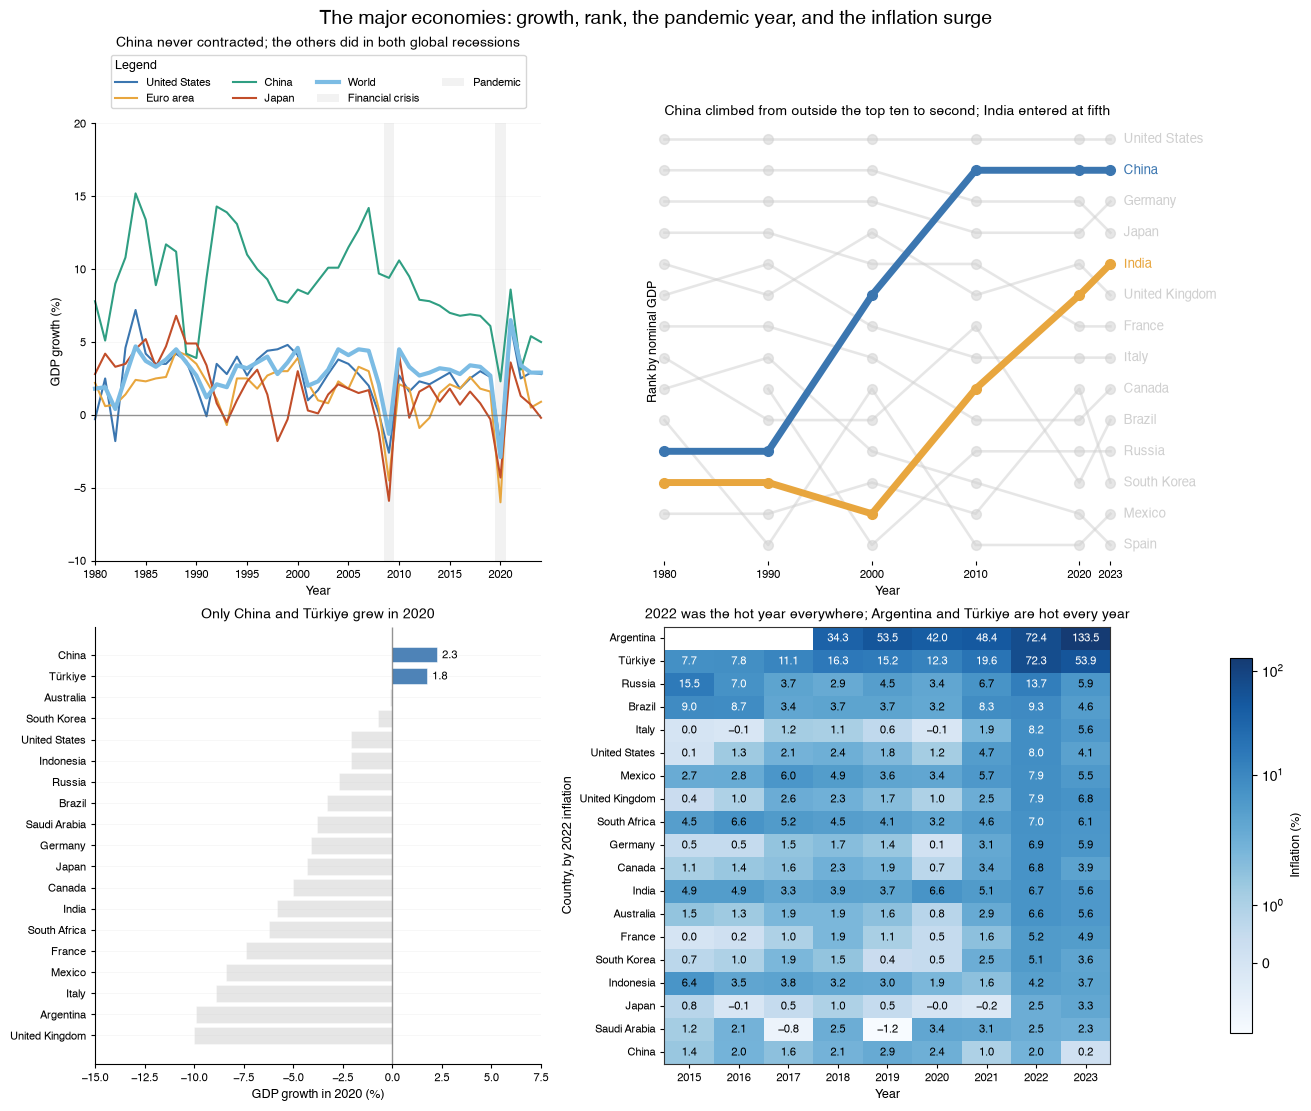

In [10]:
Grid(
    [
        [growth_figure, rank_figure],
        [pandemic_figure, inflation_figure],
    ],
    title="The major economies: growth, rank, the pandemic year, and the inflation surge",
    figsize=(13.0, 11.0),
).show()

Every figure on this page is one call to a chart function over a list of dicts, and every number in them is a World Bank series reshaped by a line or two of Python written out in the cell above it. To adapt any of them, open the guide it links to and read the parameter that does the job; the [annotations guide](../../how-to-guides/utility/annotations/) covers the reference lines, bands and notes the figures share. The charts index lists them all: [Charts](../../how-to-guides/charts/).